# Task 3: Data Visualization — Students Performance Dataset

This notebook visualizes `StudentsPerformance.csv`, covering:

1. Meaningful questions to ask before visualizing
2. Data structure check
3. Visualizations
4. Summary of findings


## 1. Meaningful Questions to Ask Before Visualization

1. **Subject comparison** — Which subject do students score highest/lowest in, on average?
2. **Gender** — What does the gender split look like?
3. **Score distribution** — What does the spread of math scores look like — normal, skewed, outliers?
4. **Inter-subject relationship** — Are math and reading scores related to each other?
5. **Spread across subjects** — How do math, reading and writing compare in terms of spread and outliers?
6. **Correlation** — How strongly are the three subjects correlated with each other?


## 2. Data Structure Check

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("StudentsPerformance.csv")

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


1000 rows, 8 columns — 5 categorical columns and 3 numerical score columns (`math score`, `reading score`, `writing score`), all on a 0–100 scale, no missing values.

## 3. Visualizations

### 3.1 Average Scores in Each Subject

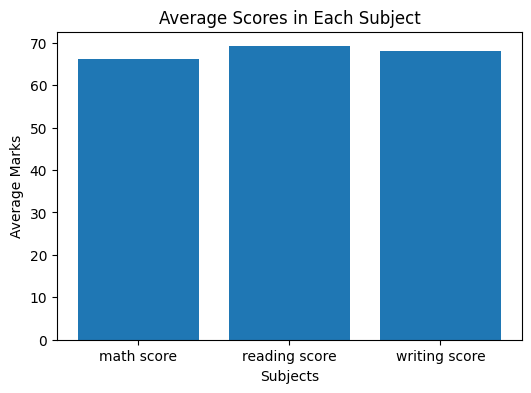

In [7]:
subjects = ["math score", "reading score", "writing score"]

average_scores = df[subjects].mean()

plt.figure(figsize=(6,4))
plt.bar(subjects, average_scores)
plt.title("Average Scores in Each Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")
plt.show()


Reading has the highest average score, followed by writing, with math the lowest of the three.

### 3.2 Gender Distribution

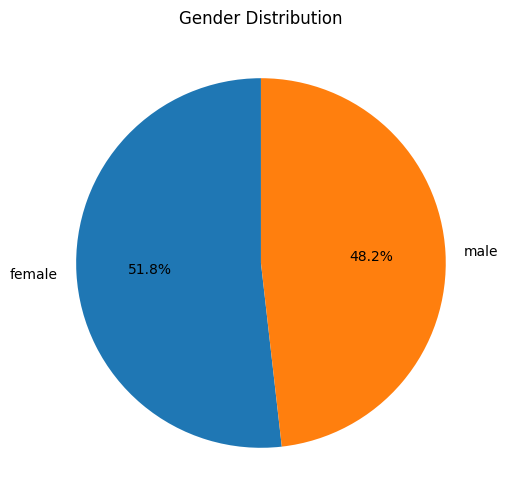

In [8]:
gender = df["gender"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender,
        labels=gender.index,
        autopct="%1.1f%%",
        startangle=90)
plt.title("Gender Distribution")
plt.show()


The gender distribution is nearly balanced, with slightly more female students.

### 3.3 Distribution of Math Scores

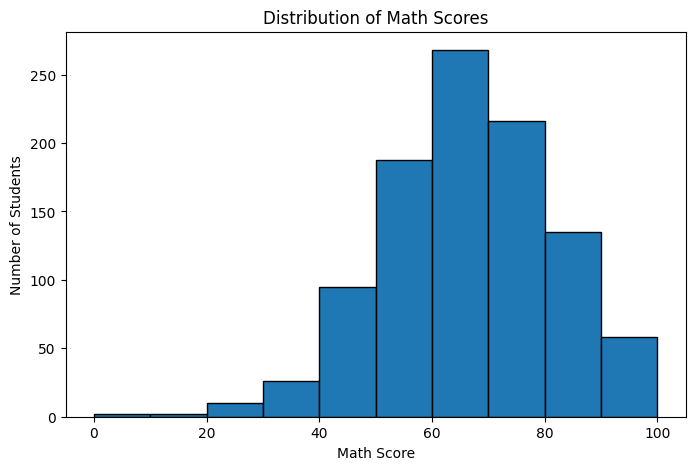

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df["math score"], bins=10, edgecolor="black")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.show()


Math scores are roughly bell-shaped and centered in the 60s-70s, with a small tail of low scorers.

### 3.4 Math Score vs Reading Score

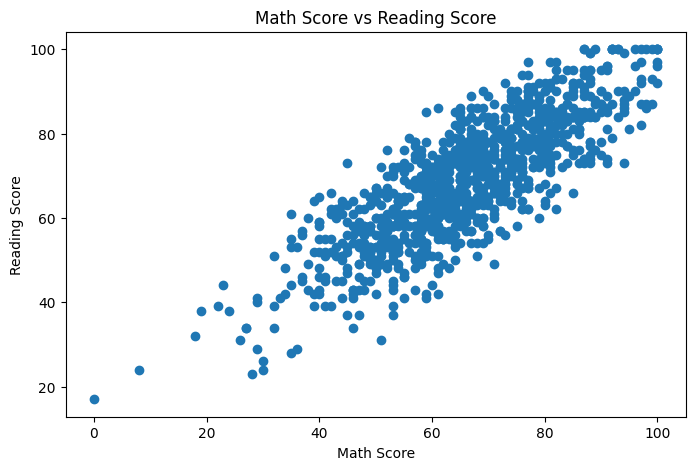

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df["math score"], df["reading score"])
plt.title("Math Score vs Reading Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.show()


There's a clear positive relationship — students who score higher in math tend to also score higher in reading.

### 3.5 Score Distribution (Boxplot)

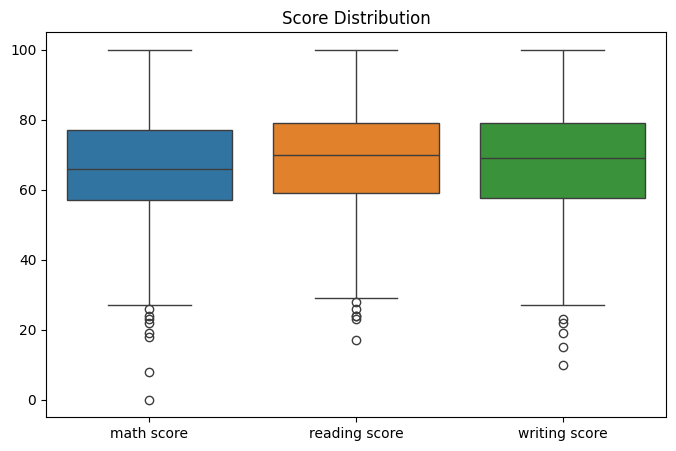

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["math score","reading score","writing score"]])
plt.title("Score Distribution")
plt.show()


All three subjects have similar medians and spread, each with a few low-end outliers.

### 3.6 Correlation Between Subjects

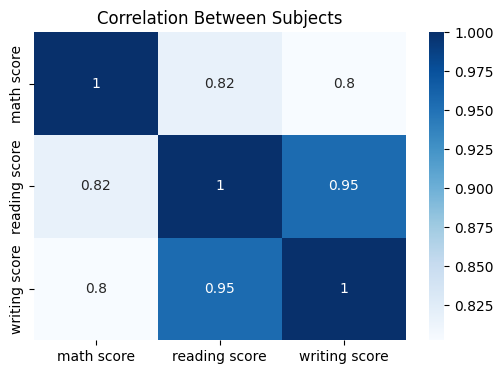

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(df[["math score","reading score","writing score"]].corr(),
            annot=True,
            cmap="Blues")
plt.title("Correlation Between Subjects")
plt.show()


All three subjects are strongly, positively correlated — reading and writing are the most closely linked.

## 4. Summary of Findings

- The dataset contains 1000 student records.
- Reading scores have the highest average among the three subjects.
- Math scores are comparatively lower.
- The gender distribution is nearly balanced, with slightly more female students.
- Reading and writing scores have a strong positive correlation.
- Data visualization makes it easier to identify trends and compare student performance.
